In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
df = pd.read_csv("../data/online_shoppers_intention.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [9]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("Missing values:")
print(df.isnull().sum())

Column names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object
Missing values:
Administrative       

In [10]:
print("Revenue distribution:")
print(df["Revenue"].value_counts())

print("\nPurchase rate:")
print(round(df["Revenue"].mean() * 100, 2), "%")

Revenue distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Purchase rate:
15.47 %


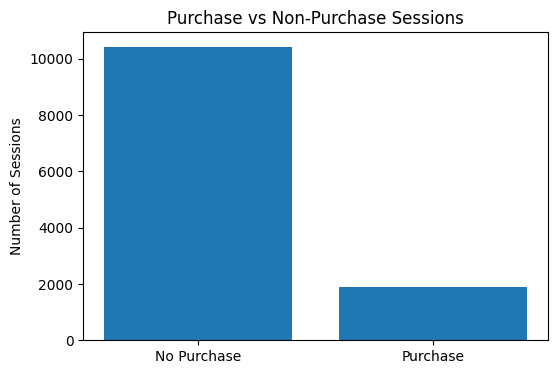

In [11]:
import matplotlib.pyplot as plt

revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Purchase", "Purchase"],
    revenue_counts.values
)

plt.title("Purchase vs Non-Purchase Sessions")
plt.ylabel("Number of Sessions")
plt.show()

In [12]:
print("Purchase rate:", round(df["Revenue"].mean() * 100, 2), "%")
print("Non-purchase rate:", round((1 - df["Revenue"].mean()) * 100, 2), "%")

Purchase rate: 15.47 %
Non-purchase rate: 84.53 %


In [13]:
# Compare average website behaviour for purchasers vs non-purchasers

df.groupby("Revenue")[
    [
        "Administrative",
        "Informational",
        "ProductRelated",
        "Administrative_Duration",
        "Informational_Duration",
        "ProductRelated_Duration",
        "BounceRates",
        "ExitRates",
        "PageValues"
    ]
].mean().round(2)

,Administrative,Informational,ProductRelated,Administrative_Duration,Informational_Duration,ProductRelated_Duration,BounceRates,ExitRates,PageValues
Revenue,,,,,,,,,
False,2.12,0.45,28.71,73.74,30.24,1069.99,0.03,0.05,1.98
True,3.39,0.79,48.21,119.48,57.61,1876.21,0.01,0.02,27.26


In [14]:
# Purchase rate by visitor type

visitor_conversion = (
    df.groupby("VisitorType")["Revenue"]
    .mean()
    .sort_values(ascending=False) * 100
)

print("Purchase rate by Visitor Type:")
print(visitor_conversion.round(2))

Purchase rate by Visitor Type:
VisitorType
New_Visitor          24.91
Other                18.82
Returning_Visitor    13.93
Name: Revenue, dtype: float64


In [15]:
# Purchase rate by weekend behaviour

weekend_conversion = (
    df.groupby("Weekend")["Revenue"]
    .mean() * 100
)

print("Purchase rate by Weekend:")
print(weekend_conversion.round(2))

Purchase rate by Weekend:
Weekend
False    14.89
True     17.40
Name: Revenue, dtype: float64


In [16]:
# Purchase rate by month

month_conversion = (
    df.groupby("Month")["Revenue"]
    .mean()
    .sort_values(ascending=False) * 100
)

print("Purchase rate by Month:")
print(month_conversion.round(2))

Purchase rate by Month:
Month
Nov     25.35
Oct     20.95
Sep     19.20
Aug     17.55
Jul     15.28
Dec     12.51
May     10.85
June    10.07
Mar     10.07
Feb      1.63
Name: Revenue, dtype: float64


In [17]:
# Number of sessions and purchase rate by month

month_analysis = df.groupby("Month")["Revenue"].agg(
    Sessions="count",
    Purchases="sum",
    Purchase_Rate="mean"
)

month_analysis["Purchase_Rate"] = (
    month_analysis["Purchase_Rate"] * 100
).round(2)

month_analysis.sort_values(
    "Purchase_Rate",
    ascending=False
)

,Sessions,Purchases,Purchase_Rate
Month,,,
Nov,2998,760,25.35
Oct,549,115,20.95
Sep,448,86,19.20
Aug,433,76,17.55
Jul,432,66,15.28
Dec,1727,216,12.51
May,3364,365,10.85
June,288,29,10.07
Mar,1907,192,10.07


In [48]:
# Feature Engineering
# Create TotalPages to represent overall browsing activity

df["TotalPages"] = (
    df["Administrative"]
    + df["Informational"]
    + df["ProductRelated"]
)

print("Feature engineering completed!")

display(
    df[
        [
            "Administrative",
            "Informational",
            "ProductRelated",
            "TotalPages"
        ]
    ].head()
)

Feature engineering completed!


,Administrative,Informational,ProductRelated,TotalPages
0,0,0,1,1
1,0,0,2,2
2,0,0,1,1
3,0,0,2,2
4,0,0,10,10


In [18]:
# Separate features and target

X = df.drop("Revenue", axis=1)
y = df["Revenue"].astype(int)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (12330, 17)
Target: (12330,)


In [49]:
from sklearn.model_selection import train_test_split

# Remove target and potentially outcome-dependent PageValues
X = df.drop(columns=["Revenue", "PageValues"])
y = df["Revenue"].astype(int)
print("TotalPages included in X:", "TotalPages" in X.columns)
print("Number of features:", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training purchase rate:", round(y_train.mean() * 100, 2), "%")
print("Testing purchase rate:", round(y_test.mean() * 100, 2), "%")

TotalPages included in X: True
Number of features: 17
Training data: (9864, 17)
Testing data: (2466, 17)
Training purchase rate: 15.47 %
Testing purchase rate: 15.49 %


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay",
    "TotalPages"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [56]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

# Metrics
print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
----------------------------
Accuracy : 0.6298
Precision: 0.2593
Recall   : 0.7487
F1 Score : 0.3852
ROC-AUC  : 0.7347

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.61      0.74      2084
           1       0.26      0.75      0.39       382

    accuracy                           0.63      2466
   macro avg       0.59      0.68      0.56      2466
weighted avg       0.83      0.63      0.68      2466


Confusion Matrix:
[[1267  817]
 [  96  286]]


In [58]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="entropy",
                max_depth=5,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [59]:
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_dt), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_dt), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 0.6395
Precision: 0.2593
Recall   : 0.7147
F1 Score : 0.3805
ROC-AUC  : 0.7319

Confusion Matrix:
[[1304  780]
 [ 109  273]]


In [54]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [67]:
# Feature Importance - Random Forest

rf_classifier = random_forest_model.named_steps["classifier"]
preprocessor_fitted = random_forest_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importances = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
display(feature_importance_df.head(15))

Top 15 Important Features:


,Feature,Importance
72,numeric__ExitRates,0.172646
70,numeric__ProductRelated_Duration,0.126297
71,numeric__BounceRates,0.083272
74,numeric__TotalPages,0.077659
69,numeric__ProductRelated,0.076636
66,numeric__Administrative_Duration,0.058305
65,numeric__Administrative,0.055877
7,categorical__Month_Nov,0.033901
68,numeric__Informational_Duration,0.021507
62,categorical__VisitorType_Returning_Visitor,0.021451


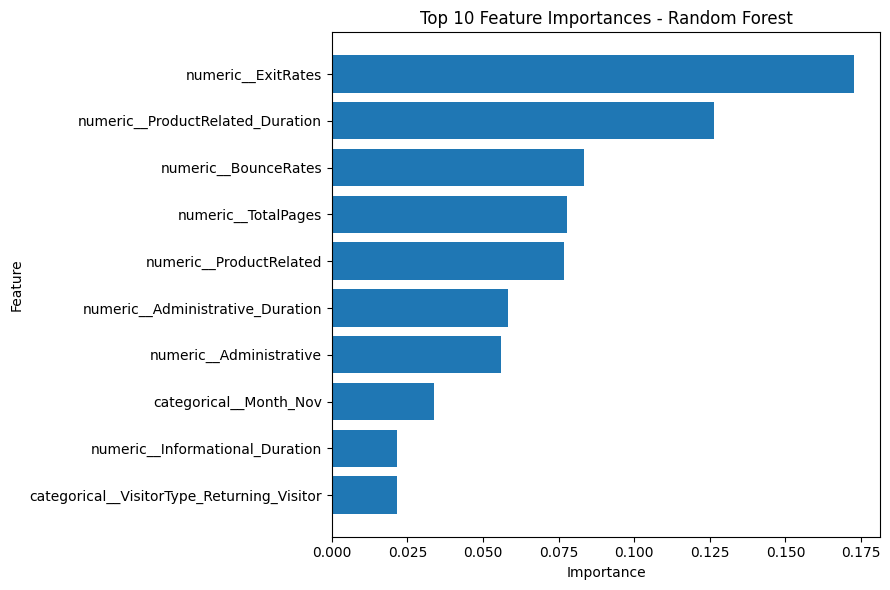

In [68]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predictions from feature-engineered Random Forest
y_pred_fe = random_forest_model.predict(X_test)
y_prob_fe = random_forest_model.predict_proba(X_test)[:, 1]

print("Feature-Engineered Random Forest Results")
print("-----------------------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_fe), 4))
print("Precision:", round(precision_score(y_test, y_pred_fe), 4))
print("Recall   :", round(recall_score(y_test, y_pred_fe), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_fe), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_fe), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_fe))

Feature-Engineered Random Forest Results
-----------------------------------------
Accuracy : 0.7064
Precision: 0.295
Recall   : 0.644
F1 Score : 0.4046
ROC-AUC  : 0.7522

Confusion Matrix:
[[1496  588]
 [ 136  246]]


In [60]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.7064
Precision: 0.295
Recall   : 0.644
F1 Score : 0.4046
ROC-AUC  : 0.7522

Confusion Matrix:
[[1496  588]
 [ 136  246]]


In [69]:
import joblib

joblib.dump(
    random_forest_model,
    "../models/online_shoppers_rf_pipeline.pkl"
)

print("Updated Random Forest pipeline saved successfully!")

Updated Random Forest pipeline saved successfully!


In [66]:
loaded_model = joblib.load(
    "../models/online_shoppers_rf_pipeline.pkl"
)

print("Updated model loaded successfully!")

Updated model loaded successfully!


In [70]:
import joblib

joblib.dump(
    random_forest_model,
    "../models/online_shoppers_rf_pipeline.pkl"
)

print("Updated Random Forest pipeline saved successfully!")

Updated Random Forest pipeline saved successfully!


In [72]:
loaded_model = joblib.load(
    "../models/online_shoppers_rf_pipeline.pkl"
)

print("Updated model loaded successfully!")

test_prediction = loaded_model.predict(X_test.iloc[:5])
test_probability = loaded_model.predict_proba(X_test.iloc[:5])[:, 1]

print("Predictions:", test_prediction)
print("Purchase probabilities:", test_probability)

Updated model loaded successfully!
Predictions: [0 0 0 0 0]
Purchase probabilities: [0.12030546 0.40668338 0.31065286 0.02287423 0.21565746]


In [71]:
loaded_model = joblib.load(
    "../models/online_shoppers_rf_pipeline.pkl"
)

print("Updated model loaded successfully!")

test_prediction = loaded_model.predict(X_test.iloc[:5])
test_probability = loaded_model.predict_proba(X_test.iloc[:5])[:, 1]

print("Predictions:", test_prediction)
print("Purchase probabilities:", test_probability)

Updated model loaded successfully!
Predictions: [0 0 0 0 0]
Purchase probabilities: [0.12030546 0.40668338 0.31065286 0.02287423 0.21565746]


In [61]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            AdaBoostClassifier(
                n_estimators=200,
                learning_rate=0.5,
                random_state=42
            )
        )
    ]
)

adaboost_model.fit(X_train, y_train)

print("AdaBoost trained successfully!")

AdaBoost trained successfully!


In [62]:
y_pred_ab = adaboost_model.predict(X_test)
y_prob_ab = adaboost_model.predict_proba(X_test)[:, 1]

print("AdaBoost Results")
print("----------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_ab), 4))
print("Precision:", round(precision_score(y_test, y_pred_ab), 4))
print("Recall   :", round(recall_score(y_test, y_pred_ab), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_ab), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_ab), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ab))

AdaBoost Results
----------------
Accuracy : 0.8447
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.7345

Confusion Matrix:
[[2083    1]
 [ 382    0]]


In [63]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("classifier", gb_classifier)
])

gb_pipeline.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print("Gradient Boosting Results")
print("-------------------------")

print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_gb, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_gb, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_gb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))

Gradient Boosting Results
-------------------------
Accuracy : 0.8427
Precision: 0.4483
Recall   : 0.0681
F1 Score : 0.1182
ROC-AUC  : 0.7595

Confusion Matrix:
[[2052   32]
 [ 356   26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      2084
           1       0.45      0.07      0.12       382

    accuracy                           0.84      2466
   macro avg       0.65      0.53      0.52      2466
weighted avg       0.79      0.84      0.79      2466



In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ab)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ab)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ab)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ab)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_ab)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.6298,0.2593,0.7487,0.3852,0.7348
1,Decision Tree,0.6403,0.2611,0.7225,0.3836,0.7392
2,Random Forest,0.7028,0.2918,0.6440,0.4016,0.7535
3,AdaBoost,0.8447,0.0000,0.0000,0.0000,0.7345


In [32]:
max_depth=10
n_estimators=200

In [33]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [8, 10, 15],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(grid_search.best_score_, 4))

Best parameters:
{'classifier__max_depth': 15, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best cross-validation ROC-AUC:
0.7786


In [34]:
# Best Random Forest from GridSearchCV
best_rf = grid_search.best_estimator_

# Predictions on untouched test data
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_best_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_best_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_best_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_best_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

Tuned Random Forest Results
---------------------------
Accuracy : 0.7798
Precision: 0.3298
Recall   : 0.4084
F1 Score : 0.3649
ROC-AUC  : 0.7572

Confusion Matrix:
[[1767  317]
 [ 226  156]]


In [35]:
# Feature importance from the original Random Forest

rf_classifier = random_forest_model.named_steps["classifier"]
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(15))

                                       Feature  Importance
72                          numeric__ExitRates    0.172647
70            numeric__ProductRelated_Duration    0.140386
69                     numeric__ProductRelated    0.099027
71                        numeric__BounceRates    0.095067
66            numeric__Administrative_Duration    0.065980
65                     numeric__Administrative    0.053186
7                       categorical__Month_Nov    0.040337
68             numeric__Informational_Duration    0.024100
41                  categorical__TrafficType_2    0.020014
62  categorical__VisitorType_Returning_Visitor    0.019968
67                      numeric__Informational    0.019009
60        categorical__VisitorType_New_Visitor    0.017660
73                         numeric__SpecialDay    0.017079
6                       categorical__Month_May    0.011287
42                  categorical__TrafficType_3    0.011227


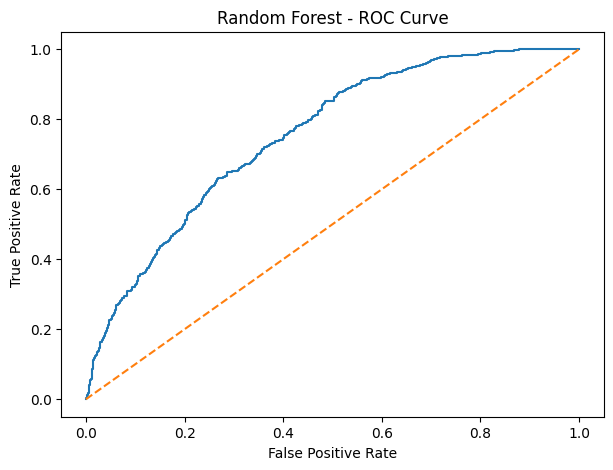

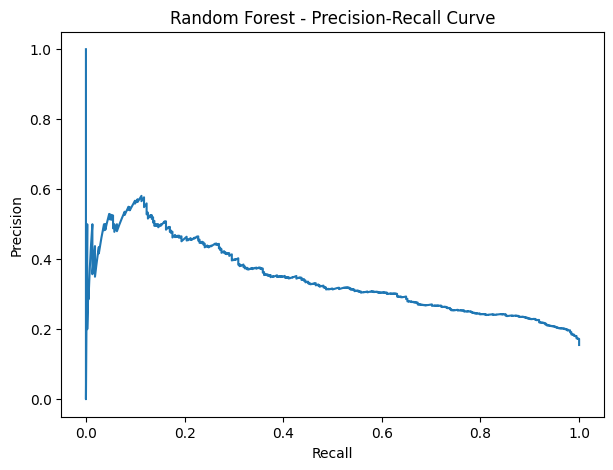

In [36]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.show()

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest - Precision-Recall Curve")
plt.show()

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds_to_test = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds_to_test:

    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4))

   Threshold  Accuracy  Precision  Recall      F1
0       0.20    0.4031     0.2022  0.9686  0.3345
1       0.25    0.4558     0.2133  0.9346  0.3473
2       0.30    0.5146     0.2292  0.9031  0.3657
3       0.35    0.5637     0.2418  0.8508  0.3766
4       0.40    0.5981     0.2477  0.7827  0.3763
5       0.45    0.6492     0.2662  0.7199  0.3887
6       0.50    0.7028     0.2918  0.6440  0.4016


In [44]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the complete tuned pipeline
joblib.dump(
    best_rf,
    "../models/online_shoppers_rf_pipeline.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [45]:
# Load the saved model
loaded_model = joblib.load(
    "../models/online_shoppers_rf_pipeline.pkl"
)

# Test prediction
test_prediction = loaded_model.predict(X_test.iloc[:5])
test_probability = loaded_model.predict_proba(X_test.iloc[:5])[:, 1]

print("Model loaded successfully!")
print("Predictions:", test_prediction)
print("Purchase probabilities:", test_probability)

Model loaded successfully!
Predictions: [0 0 0 0 0]
Purchase probabilities: [0.05038006 0.31470445 0.31078933 0.01131986 0.18166922]


In [47]:
import pandas as pd

# Load your original dataset
df = pd.read_csv("../data/online_shoppers_intention.csv")

# Select only actual purchasers
purchasers = df[df["Revenue"] == True].copy()

# Features used by your prediction model
features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

# Display 5 real purchasing sessions
real_purchasers = purchasers[features].head(5)

print("Total real purchasing sessions:", len(purchasers))
print("\n5 REAL PURCHASER PROFILES:")
display(real_purchasers)

Total real purchasing sessions: 1908

5 REAL PURCHASER PROFILES:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
65,3,87.833333,0,0.0,27,798.333333,0.000000,0.012644,22.916036,0.8,Feb,2,2,3,1,Returning_Visitor,False
76,10,1005.666667,0,0.0,36,2111.341667,0.004348,0.014493,11.439412,0.0,Feb,2,6,1,2,Returning_Visitor,False
101,4,61.000000,0,0.0,19,607.000000,0.000000,0.026984,17.535959,1.0,Feb,1,1,7,4,Returning_Visitor,True
188,9,111.500000,1,48.5,49,1868.819697,0.000000,0.020709,1.706015,0.0,Mar,2,2,7,2,Returning_Visitor,False
196,2,56.000000,1,144.0,67,2563.783333,0.000000,0.005797,19.342650,0.0,Mar,2,2,4,2,New_Visitor,False
